In [1]:
from dotenv import load_dotenv
from langchain_openai import OpenAIEmbeddings
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ['PINECONE_API_KEY'] = os.getenv('PINECONE_API_KEY')

# Agentic RAG

https://docs.langchain.com/oss/python/langgraph/agentic-rag

![](https://mintcdn.com/langchain-5e9cc07a/I6RpA28iE233vhYX/images/langgraph-hybrid-rag-tutorial.png?w=1100&fit=max&auto=format&n=I6RpA28iE233vhYX&q=85&s=2425baddda7209901bdde4425c23292c)

### 1. Indexing
외부 문서를 임베딩을 거쳐 벡터스토어에 저장

In [2]:
from langchain_community.document_loaders import WebBaseLoader

urls = [
    'https://lilianweng.github.io/posts/2026-07-04-harness/',
    'https://lilianweng.github.io/posts/2026-06-24-scaling-laws/',
    'https://lilianweng.github.io/posts/2025-05-01-thinking/',
]

docs  = []
for url in urls:
    loader = WebBaseLoader(url) # 해당 URL용 로더 생성
    doc = loader.load()                   # 웹페이지 내용을 Document로 변환 ([] 반환)
    docs.append(doc)

print(len(docs))
print(docs) # [[Document], [Document], [Document]]

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_43204\77474327.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


3
[[Document(metadata={'source': 'https://lilianweng.github.io/posts/2026-07-04-harness/', 'title': "Harness Engineering for Self-Improvement | Lil'Log", 'description': 'The concept of recursive self-improvement (RSI) dates back to I. J. Good (1965), where he defined an “ultraintelligent machine” as a system that can surpass humans in all intellectual activities and design better machines to improve itself. Yudkowsky (2008) used the phrase “recursive self-improvement” for a specific feedback loop: an AI uses its current intelligence to improve the cognitive machinery that produces its intelligence.\nThis feedback loop in modern AI may indicate the model rewriting its own weights directly, or more broadly the model improves the training pipeline and the deployment system, which in turn enables a better successor model with improved performance across economically valuable tasks. The speed of research development in AI has been shown to drastically accelerated in frontier labs (Anthropic

In [3]:
print(docs[0][0].page_content)







Harness Engineering for Self-Improvement | Lil'Log






































Lil'Log

















|






Posts




Archive




Search




Tags




FAQ









      Harness Engineering for Self-Improvement
    
Date: July 4, 2026  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng


 


Table of Contents



Harness Design Patterns

Pattern 1: Workflow Automation

Pattern 2: File System as Persistent Memory

Pattern 3: Sub-agent and Backend Jobs

Case study: Coding Agent Harness

Harness Layer vs Core Intelligence?


Harness Optimization

Context Engineering

Workflow Design

Self-Improving Harness

Evolutionary Search

Joint Optimization with Model Weights


Future Challenges

Citation

Appendix: Some useful benchmarks

References





The concept of recursive self-improvement (RSI) dates back to I. J. Good (1965), where he defined an “ultraintelligent machine” as a system that can surpass humans in all intellectual activities and design better machines t

In [4]:
# 리스트를 1차원으로 펼치고, 청킹
from langchain_text_splitters import RecursiveCharacterTextSplitter

# [[Document], [Document], [Document]] -> [Document, ...]
docs_list = [item for sublist in docs for item in sublist]

# 토큰기반 문서 청킹용 분할기
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size = 100,   # 최대 토큰 크기
    chunk_overlap = 30  # 겹친 토큰 크기
)
# Document 리스트를 청크 Document들로 분할
docs_splits = text_splitter.split_documents(docs_list) 
print(len(docs_splits))
print(docs_splits)

537
[Document(metadata={'source': 'https://lilianweng.github.io/posts/2026-07-04-harness/', 'title': "Harness Engineering for Self-Improvement | Lil'Log", 'description': 'The concept of recursive self-improvement (RSI) dates back to I. J. Good (1965), where he defined an “ultraintelligent machine” as a system that can surpass humans in all intellectual activities and design better machines to improve itself. Yudkowsky (2008) used the phrase “recursive self-improvement” for a specific feedback loop: an AI uses its current intelligence to improve the cognitive machinery that produces its intelligence.\nThis feedback loop in modern AI may indicate the model rewriting its own weights directly, or more broadly the model improves the training pipeline and the deployment system, which in turn enables a better successor model with improved performance across economically valuable tasks. The speed of research development in AI has been shown to drastically accelerated in frontier labs (Anthropi

In [5]:
# InMemoryVectorStore를 활용하여 임시 벡터 DB 구성

from langchain_core.vectorstores import InMemoryVectorStore
from langchain_openai import OpenAIEmbeddings


# 임베딩 모델 생성
embeddings = OpenAIEmbeddings(
    model='text-embedding-3-small'
)


# 청크 문서를 임베딩해서 저장한 벡터스토어 생성
vectorstore = InMemoryVectorStore.from_documents(
    docs_splits,
    embedding=embeddings
)


retriever = vectorstore.as_retriever()

retriever.invoke(
    'Causes Hallucinations'
)

[Document(id='562f2798-be2a-4327-bf25-978fab8043fc', metadata={'source': 'https://lilianweng.github.io/posts/2025-05-01-thinking/', 'title': "Why We Think | Lil'Log", 'description': 'Special thanks to John Schulman for a lot of super valuable feedback and direct edits on this post.\nTest time compute (Graves et al. 2016, Ling, et al. 2017, Cobbe et al. 2021) and Chain-of-thought (CoT) (Wei et al. 2022, Nye et al. 2021), have led to significant improvements in model performance, while raising many research questions. This post aims to review recent developments in how to effectively use test-time compute (i.e. “thinking time”) and why it helps.', 'language': 'en-us'}, page_content='other types of hallucinations. These two methods can be used together. Snell et al. (2024) showed that easier questions benefit from purely sequential test-time compute, whereas harder questions often perform best with an optimal ratio of sequential to parallel compute.'),
 Document(id='4a26bf59-82b5-4621-af8

In [6]:
# 검색기를 Tool 형태로 생성
from langchain_core.tools import tool # 함수 -> Tool 변환 데코레이터

@tool
def retrieve_blog_posts(query: str)-> str:
    ''' Lilian Weng의 블로그 글을 검색하고 정보를 획득하는 도구'''
    docs = retriever.invoke(query)
    return '\n\n'.join([doc.page_content for doc in docs])

print(retrieve_blog_posts.invoke('Causes Hallucinations'))

other types of hallucinations. These two methods can be used together. Snell et al. (2024) showed that easier questions benefit from purely sequential test-time compute, whereas harder questions often perform best with an optimal ratio of sequential to parallel compute.

hallucination, including modifying correct responses to be incorrect; (2) behavior collapse to non-correcting behavior; e.g. making minor or no modification on the first incorrect responses; or (3) fail to generalize to distribution shift at test time. Experiments by Huang et al. (2024) showed that naively applying self-correction leads to worse performance and external feedback is needed for models to self improve, which can be based on matching ground truths, heuristics

Memory and context degradation: long-horizon projects lose critical details unless logs are written as persistent artifacts.
Over-optimism: the model declares success despite noisy or failed experiments, similarly observed as “p-hacking and eureka-in

In [7]:
retrieve_blog_posts.invoke('Harness')

'Self-Improving Harness#\n\nHarness proposal: propose bounded harness edits based on mined failure patterns.\n\nHarness Design Patterns#\nCompared with early agent frameworks, “agent = LLM + memory + tools + planning + action”, harnesses engineering additionally include workflow design (e.g. loop engineering), evaluation, permission controls, and persistent state management. It is no longer only prompt templates, but closer to runtime and software system design: how the model observes, acts, memorizes, checks itself, and improves.\n\nAgentic Harness Engineering (AHE; Lin et al. 2026) see the bottlenecks of harness evolution are around observability—that is, when a rollout fails, we need to know which component is responsible for that and every edit should be grounded by evidence.\nThe framework creates a closed loop with 3 observability pillars:'

2. Retrieval & Generation
사용자의 요청에 필요한 외부문서를 검색하고, 이를 기반으로 응답


Generate Query Agent

In [8]:
from langgraph.graph import MessagesState # Langgraph 메시지 타입
from langchain.chat_models import init_chat_model

response_model = init_chat_model('gpt-5.4-mini', temperature = 0)
response_model_with_tools = response_model.bind_tools([retrieve_blog_posts]) # tool 바인딩

def generate_query_or_respond(state: MessagesState):
    response = response_model_with_tools.invoke(state['messages']) # LLM 호출
    return {'messages': [response]} # Langgraph messages 형태로 반환

In [9]:
state = {'messages': [('human', '환각이란 무엇인가?')]}
response = generate_query_or_respond(state)
print(response)

{'messages': [AIMessage(content='“환각”은 보통 **실제로는 없는 대상이나 소리, 냄새, 감각을 실제처럼 지각하는 경험**을 뜻합니다.\n\n예를 들면:\n- 아무도 없는데 **목소리가 들리는 것**\n- 존재하지 않는 **그림자나 사람을 보는 것**\n- 실제 자극이 없는데 **벌레가 기어가는 느낌**이 드는 것\n\n의학적으로는 정신질환, 수면 부족, 약물, 알코올, 고열, 신경계 질환 등 여러 원인으로 나타날 수 있습니다.\n\n원하시면 제가 이어서:\n1. **환각과 착각의 차이**\n2. **환각의 종류**\n3. **환각이 생기는 원인**\n4. **언제 병원에 가야 하는지**\n\n이렇게 쉽게 정리해드릴게요.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 190, 'prompt_tokens': 145, 'total_tokens': 335, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EKED1at109c6TS64bobXQXk8u9sZs', 'service_tier': 'default', 'finish_reason': 'st

In [10]:
state = {'messages': [('human', 'Lilian Weng이 블로그에서 말하는 환각이란 무엇인가?')]}
response = generate_query_or_respond(state)
print(response)

{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 155, 'total_tokens': 184, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EKED3ixrMxgYFsL2jAk1J0lOXutYR', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a06a4d-f33d-77e1-90ab-3ea47b2016c6-0', tool_calls=[{'name': 'retrieve_blog_posts', 'args': {'query': 'Lilian Weng blog hallucination what is hallucination definition'}, 'id': 'call_LgBGEAmU2L2ldJUMCTIBatfn', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 155,

### Grade Document Agent (conditional edge function)

조회된 문서를 평가하여 사용자의 질문과 적합한지를 판단
- generate_andwer : "yes"
- rewrite_query = "no"

In [11]:
from pydantic import BaseModel, Field
from typing import Literal
from langchain_core.prompts import PromptTemplate

GRADE_PROMPT = (  # 문서-질문 관련성 평가용 프롬프트
    "귀하는 검색된 문서가 사용자 질문과 관련이 있는지 평가하는 평가자입니다. \n "
    "검색된 문서는 다음과 같습니다: \n\n {context} \n\n "
    "사용자 질문은 다음과 같습니다: {question} \n "
    "문서에 사용자 질문과 관련된 키워드 또는 의미론적 의미가 포함되어 있으면 관련성 있음으로 평가하세요. \n "
    "문서가 질문과 관련이 있는지 여부를 나타내는 이진 점수('yes' 또는 'no')를 부여하세요."
)

class GradeDocuments(BaseModel):
    binary_score: str = Field(description = "관련이 있으면 'yes'를, 없으면 'no'를 작성하세요.")

grader_model = init_chat_model('gpt-5.6-luna')

# 검색 결과(context)가 질문(question)과 관련 있는지 판단 후, 다음 노드 라우팅 함수
def grade_documents(state: MessagesState) -> Literal['generate_answer', 'rewrite_query']:
    question = state['messages'][0].content # 사용자 질문
    context = state['messages'][-1].content # 검색 결과

    prompt = PromptTemplate.from_template(GRADE_PROMPT)
    # LLM 출력 JSON -> GradeDocument로 파싱
    chain = prompt | grader_model.with_structured_output(GradeDocuments)
    response = chain.invoke({'question': question, 'context': context})
 
    score = response.binary_score # 구조화 출력에서 답변내용 (yes/no)
    if score == 'yes':
        return 'generate_answer'
    else:
        return 'rewrite_query'

In [12]:
# generate_answer인 경우 테스트

from langchain_core.messages import AIMessage, ToolMessage, HumanMessage

messages = [  # 테스트용 대화 흐름 구성
    HumanMessage(content='What does Lilien Weng says about harness?'),  # 사용자 질문
    AIMessage(  # 모델이 Tool 호출을 하도록 만든 메시지(내용은 비워도 됨)
        content='',  # Tool call만 수행하는 상황을 가정
        tool_calls=[  # 어떤 도구를 어떤 인자로 호출했는지 기록
            {
                'id': "1",  # tool call 식별자
                'name': 'retrieve_blog_posts',  # 호출할 Tool 이름
                'args': {'query': 'reward hacking'}  # Tool 입력값
            }
        ]
    ),
    ToolMessage(  # Tool 실행 결과(검색된 컨텍스트)를 담는 메시지
        tool_call_id="1",  # 위 tool call id와 매칭
        content='''  # 검색 결과(문서 일부) 텍스트
Why does Reward Hacking Exist?#

Detecting Reward Hacking#

In-Context Reward Hacking#

(Note: Some work defines reward tampering as a distinct category of misalignment behavior from reward hacking. But I consider reward hacking as a broader concept here.)
At a high level, reward hacking can be categorized into two types: environment or goal misspecification, and reward tampering.
'''
    )
]

grade_documents({'messages': messages})

'rewrite_query'

In [13]:
from langchain_core.messages import HumanMessage

REWRITE_PROMPT = (  # 질문 재작성용 프롬프트 템플릿
    "입력된 내용을 바탕으로 사용자의 근본적인 의도와 의미를 분석한다. \n "
    "다음은 초기 질문이다:"
    " \n  -------  \n "
    " {question} "
    " \n  -------  \n "
    "분석한 의도를 반영하여 더 명확하고 구체적인 질문으로 재구성한다:"
)

def rewrite_query(state: MessagesState):
    question = state['messages'][0].content # 사용자 질문

    chain = PromptTemplate.from_template(REWRITE_PROMPT) | response_model
    response = chain.invoke({'question': question})
    # 재작성된 검색어를 사용자 메시지로 추가해야 다음 단계에서 다시 검색할 수 있음
    return {'messages': [HumanMessage(content=response.content)]}

Generate Answer Agent

In [14]:
GENERATE_PROMPT = (  # 컨텍스트 기반 답변 생성용 프롬프트
    "귀하는 질문-답변 작업을 위한 도우미입니다. "
    "제공된 검색된 컨텍스트 조각을 사용하여 질문에 답변하세요. "
    "답변을 모르면 모른다고 말하세요. "
    "최대 세 문장을 사용하고 답변을 간결하게 유지하세요. \n "
    "(한국어로 답변해주세요) \n "
    "질문:  {question}   \n "
    "컨텍스트:  {context} "
)

def generate_answer(state: MessagesState):
    question = state['messages'][0].content # 사용자 질문
    context = state['messages'][-1].content

    chain = PromptTemplate.from_template(GENERATE_PROMPT) | response_model
    response = chain.invoke({'question': question, 'context': context})
    return {'messages': [response]} # langgraph messages 형태로 반환

Generate_Answer_Test

In [15]:
# generate_answer인 경우 테스트

from langchain_core.messages import AIMessage, ToolMessage, HumanMessage

messages = [  # 테스트용 대화 흐름 구성
    HumanMessage(content='What does Lilian Weng say about a harness?'),  # 사용자 질문
    AIMessage(  # 모델이 Tool 호출을 하도록 만든 메시지(내용은 비워도 됨)
        content='',  # Tool call만 수행하는 상황을 가정
        tool_calls=[  # 어떤 도구를 어떤 인자로 호출했는지 기록
            {
                'id': "1",  # tool call 식별자
                'name': 'retrieve_blog_posts',  # 호출할 Tool 이름
                'args': {'query': 'Lilian Weng harness definition'}  # Tool 입력값
            }
        ]
    ),
    ToolMessage(  # Tool 실행 결과(검색된 컨텍스트)를 담는 메시지
        tool_call_id="1",  # 위 tool call id와 매칭
        content='''  # 검색 결과(문서 일부) 텍스트
A harness is the system surrounding a base model that orchestrates execution and decides how the model thinks and plans, calls tools and acts, perceives and manages context, stores artifacts, and evaluates results.
'''
    )
]

print('route:', grade_documents({'messages': messages}))

response = generate_answer({'messages': messages})
print(response['messages'][-1].content)

route: generate_answer
Lilian Weng은 하니스(harness)를 **기본 모델을 둘러싸는 시스템**이라고 설명합니다. 이 시스템은 모델의 실행을 조율하고, 생각·계획·도구 호출·행동·인지·문맥 관리·산출물 저장·결과 평가를 담당합니다.


그래프 생성

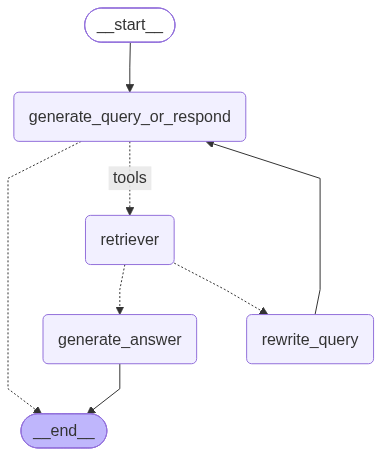

In [16]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

workflow = StateGraph(MessagesState)

workflow.add_node(generate_query_or_respond)
workflow.add_node("retriever", ToolNode([retrieve_blog_posts]))
workflow.add_node(generate_answer)
workflow.add_node(rewrite_query)

# 엣지 구성
workflow.add_edge(START, 'generate_query_or_respond')
workflow.add_conditional_edges(
    'generate_query_or_respond',
    tools_condition,
    {
        'tools': 'retriever',
        END: END
    }
)

workflow.add_conditional_edges(
    'retriever',
    grade_documents
)
workflow.add_edge('generate_answer', END)
workflow.add_edge('rewrite_query', 'generate_query_or_respond')

graph = workflow.compile()
graph

In [17]:
# 스트리밍 실행
for chunk in graph.stream({'messages': [('human', 'Lilian Weng은 하네스를 뭐라고 정의한거야?')]}):

    for node_name, update in chunk.items():
        print(f"{node_name}")
        update['messages'][-1].pretty_print()
        print()

generate_query_or_respond
================================== Ai Message ==================================
Tool Calls:
  retrieve_blog_posts (call_yCXkwmviPP82MC4a4blkcs7H)
 Call ID: call_yCXkwmviPP82MC4a4blkcs7H
  Args:
    query: Lilian Weng harness defined as blog post harness definition

retriever
================================= Tool Message =================================
Name: retrieve_blog_posts

Weng, Lilian. “Harness Engineering for Self-Improvement”. Lil’Log (Jul 2026). https://lilianweng.github.io/posts/2026-07-04-harness/

Or use the BibTeX citation:
@article{weng2026harness,
  title = {Harness Engineering for Self-Improvement},
  author = {Weng, Lilian},
  journal = {lilianweng.github.io},
  year = {2026},
  month = {July},

for defining programs and systems. In simple words, a harness is code that programs how prompts, tool calls, subagents, control flow, memory, and workflow logic work together. If an LLM can optimize the code that executes agents, it can access a mu